# Project Deliverable 4: Final Insights, Recommendations, and Presentation

## Consolidated Project Summary
This final notebook consolidates the project journey using the UCI Red Wine Quality dataset: data preparation and EDA, feature engineering, regression, classification, clustering, association rules, ethical considerations, and recommendations.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

SCREENSHOTS=Path('screenshots'); SCREENSHOTS.mkdir(exist_ok=True)
wine=pd.read_csv('data/winequality-red-cleaned-project-d1.csv')
print(wine.shape)
wine.head()

(1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


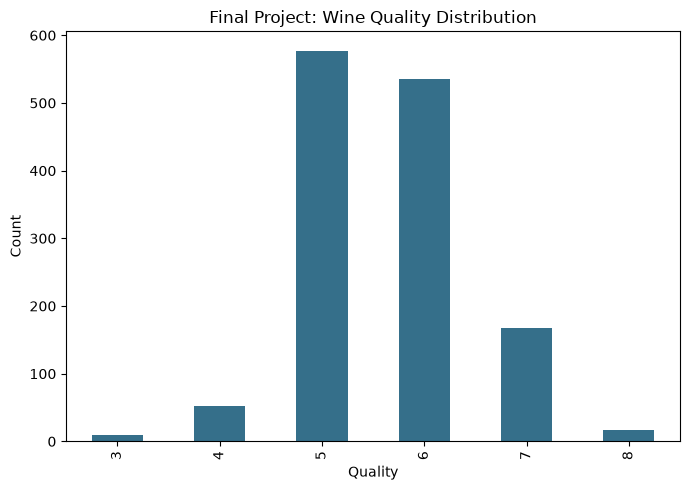

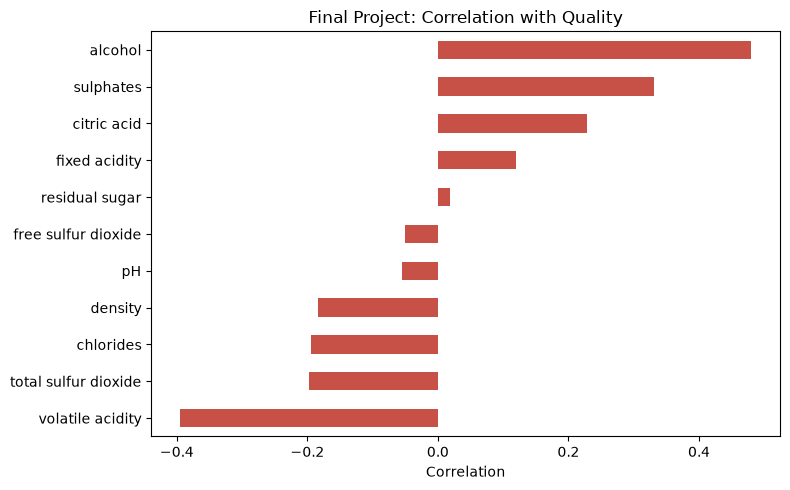

In [2]:
plt.figure(figsize=(7,5))
wine['quality'].value_counts().sort_index().plot(kind='bar', color='#356f8a')
plt.title('Final Project: Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d4_quality_distribution.png', dpi=160)
plt.show()

corr=wine.corr(numeric_only=True)['quality'].sort_values()
plt.figure(figsize=(8,5))
corr.drop('quality').plot(kind='barh', color='#c75146')
plt.title('Final Project: Correlation with Quality')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d4_quality_correlations.png', dpi=160)
plt.show()

In [3]:
wine_fe=wine.copy()
wine_fe['free_to_total_sulfur_ratio']=wine_fe['free sulfur dioxide']/wine_fe['total sulfur dioxide'].replace(0,np.nan)
wine_fe['acid_balance']=wine_fe['fixed acidity']-wine_fe['volatile acidity']
wine_fe['alcohol_sulphates_interaction']=wine_fe['alcohol']*wine_fe['sulphates']
wine_fe=wine_fe.replace([np.inf,-np.inf],np.nan).fillna(wine_fe.median(numeric_only=True))

X=wine_fe.drop(columns=['quality'])
y=wine_fe['quality']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
ridge=Pipeline([('scaler',StandardScaler()),('model',Ridge(alpha=10.0))])
ridge.fit(X_train,y_train)
pred=ridge.predict(X_test)
reg_summary={'R2':r2_score(y_test,pred),'MSE':mean_squared_error(y_test,pred),'RMSE':np.sqrt(mean_squared_error(y_test,pred))}
reg_summary

{'R2': 0.4161847025366112,
 'MSE': 0.4135489875400603,
 'RMSE': np.float64(0.643077746108556)}

In [4]:
wine_cls=wine.copy()
wine_cls['quality_class']=(wine_cls['quality']>=6).astype(int)
Xc=wine_cls.drop(columns=['quality','quality_class'])
yc=wine_cls['quality_class']
Xc_train,Xc_test,yc_train,yc_test=train_test_split(Xc,yc,test_size=.2,random_state=42,stratify=yc)
knn=Pipeline([('scaler',StandardScaler()),('model',KNeighborsClassifier(n_neighbors=11,weights='distance'))])
knn.fit(Xc_train,yc_train)
cpred=knn.predict(Xc_test)
class_summary={'Accuracy':accuracy_score(yc_test,cpred),'F1':f1_score(yc_test,cpred)}
class_summary

{'Accuracy': 0.7279411764705882, 'F1': 0.7448275862068966}

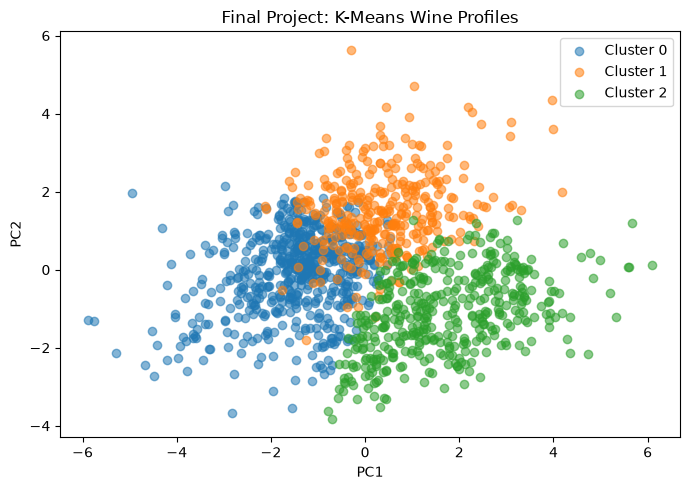

,quality,alcohol,volatile acidity,sulphates
cluster,,,,
0,5.537,10.557,0.608,0.606
1,5.316,9.815,0.551,0.627
2,5.991,10.759,0.403,0.730


In [5]:
Xs=StandardScaler().fit_transform(wine.drop(columns=['quality']))
clusters=KMeans(n_clusters=3,random_state=42,n_init=20).fit_predict(Xs)
coords=PCA(n_components=2, random_state=42).fit_transform(Xs)
plt.figure(figsize=(7,5))
for c in sorted(set(clusters)):
    mask=clusters==c
    plt.scatter(coords[mask,0],coords[mask,1],alpha=.55,label=f'Cluster {c}')
plt.title('Final Project: K-Means Wine Profiles')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.tight_layout()
plt.savefig(SCREENSHOTS/'d4_clusters.png', dpi=160)
plt.show()

final_summary=wine.assign(cluster=clusters).groupby('cluster')[['quality','alcohol','volatile acidity','sulphates']].mean().round(3)
final_summary

## Final Recommendations
1. Preserve alcohol, volatile acidity, sulphates, density, and engineered balance variables in future models because they repeatedly appear useful.  
2. Treat model outputs as decision support rather than deterministic quality judgments because wine quality is partly sensory and subjective.  
3. Use classification for practical screening and regression for approximate score prediction.  
4. Use clustering to profile wine styles and guide business or product-development questions.  
5. Monitor bias and fairness concerns because the dataset represents a specific wine type and region, so conclusions should not be generalized to all wines without validation.

In [6]:
pd.DataFrame([reg_summary]).to_csv('data/d4_regression_summary.csv', index=False)
pd.DataFrame([class_summary]).to_csv('data/d4_classification_summary.csv', index=False)
final_summary.to_csv('data/d4_cluster_summary.csv')
print('Saved final summaries and visualizations.')

Saved final summaries and visualizations.
